# Importing libraries

In [4]:
from pathlib import Path
import requests 
import holidays
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Paths based on structure
PROJECT_DIR = Path("..")
REF_DIR = PROJECT_DIR / "data" / "reference"

REF_DIR.mkdir(parents=True, exist_ok=True)

# Holiday feature extraction

In [11]:
# Setting the location of Mexico City as well as the time zone
start_date = "2018-01-01"
end_date = "2025-12-31"

years = range(2018, 2026)

mx_holidays = holidays.Mexico(years=years)

In [12]:
# Holiday data frame and check
holiday_raw = pd.DataFrame([
    {
        "date": pd.to_datetime(date).date(),
        "holiday_name": name,
        "is_holiday": 1
    }
    for date, name in mx_holidays.items()
])

holiday_raw = holiday_raw.sort_values("date").reset_index(drop=True)

print(holiday_raw.shape)

(58, 3)


- Only 57 holidays in total between 2018—2025

In [14]:
# Calendar for the dataset
calendar = pd.DataFrame({
    "date": pd.date_range(start_date, end_date, freq="D").date
})

calendar = calendar.merge(
    holiday_raw,
    on="date",
    how="left"
)

calendar["is_holiday"] = calendar["is_holiday"].fillna(0).astype(int)
calendar["holiday_name"] = calendar["holiday_name"].fillna("None")

print(calendar.shape)
calendar.head()

(2922, 3)


,date,holiday_name,is_holiday
0,2018-01-01,New Year's Day,1
1,2018-01-02,None,0
2,2018-01-03,None,0
3,2018-01-04,None,0
4,2018-01-05,None,0


In [17]:
calendar["year"] = calendar["date_dt"].dt.year
calendar["month"] = calendar["date_dt"].dt.month
calendar.head()

,date,holiday_name,is_holiday,date_dt,year,month,weekday,is_weekend_calendar
0,2018-01-01,New Year's Day,1,2018-01-01,2018,1,0,0
1,2018-01-02,None,0,2018-01-02,2018,1,1,0
2,2018-01-03,None,0,2018-01-03,2018,1,2,0
3,2018-01-04,None,0,2018-01-04,2018,1,3,0
4,2018-01-05,None,0,2018-01-05,2018,1,4,0


# Summary statistics

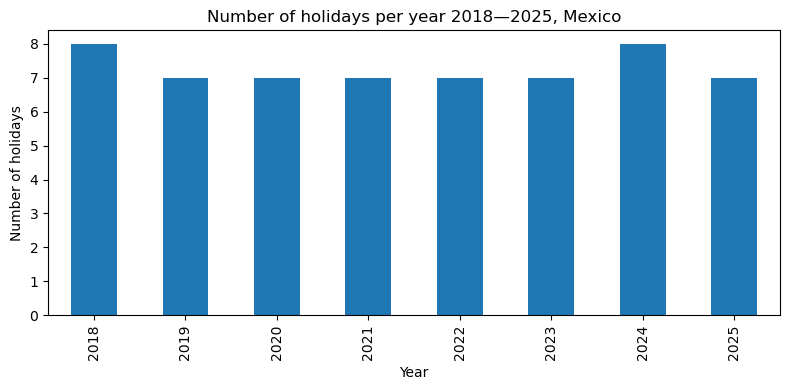

In [19]:
# Holidays per year
calendar.groupby("year")["is_holiday"].sum().plot(kind="bar", figsize=(8, 4))
plt.title("Number of holidays per year 2018—2025, Mexico")
plt.xlabel("Year")
plt.ylabel("Number of holidays")
plt.tight_layout()
plt.show()

In [21]:
holiday_features = calendar[
    [
        "date",
        "is_holiday",
        "holiday_name",
    ]
].copy()

holiday_features.head()

,date,is_holiday,holiday_name
0,2018-01-01,1,New Year's Day
1,2018-01-02,0,None
2,2018-01-03,0,None
3,2018-01-04,0,None
4,2018-01-05,0,None


In [22]:
# Save to references for modeling
holiday_path = REF_DIR / "mx_holidays.parquet"

holiday_features.to_parquet(holiday_path, index=False)

print("Saved:", holiday_path.resolve())

Saved: /Users/francobastida/Desktop/ecobici/data/reference/mx_holidays.parquet


In [ ]:
# Merge test to check datetime
station_hour_path = Path("../outputs/ecobici_station_hour.parquet")

df = pd.read_parquet(station_hour_path)

df["datetime_hour"] = pd.to_datetime(df["datetime_hour"])
df["date"] = df["datetime_hour"].dt.date

test_merge = df[["station_id", "datetime_hour", "date", "departures"]].head(100_000).merge(
    holiday_features,
    on="date",
    how="left"
)

test_merge.head()

,station_id,datetime_hour,date,departures,is_holiday,holiday_name
0,1,2018-01-01,2018-01-01,0,1,New Year's Day
1,6,2018-01-01,2018-01-01,3,1,New Year's Day
2,9,2018-01-01,2018-01-01,1,1,New Year's Day
3,16,2018-01-01,2018-01-01,7,1,New Year's Day
4,18,2018-01-01,2018-01-01,14,1,New Year's Day
